# 04 Transformer Model - BioBERT

This notebook fine-tunes **BioBERT** on the combined **FakeHealth + healthfact** binary misinformation dataset.


**BioBERT** because it is a stronger domain-specific model for biomedical and health language than general model like DistilBERT.our task is health misinformation detection, this gives us a more meaningful transformer benchmark for medical claims, health news, and public health text.

current environment is **CPU-only**, so BioBERT training will be slower than GPU training. To keep the first run realistic in Jupyter Notebook, this notebook starts with conservative settings:

- `num_train_epochs = 1`to 5
- `per_device_train_batch_size = 4`
- `gradient_accumulation_steps = 2`
- `max_length = 256`

Once the first run completes successfully, you can increase the epochs to `2` or `3` for a stronger result.


## Model Download
- `dmis-lab/biobert-base-cased-v1.1`


In [1]:
from pathlib import Path
import json
import os
import random

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)


C:\Users\ribam\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROJECT_ROOT = Path(r'C:\Users\ribam\Desktop\Reseach\Dataset')
DATA_PATH = PROJECT_ROOT / 'dataset' / 'processed' / 'fakehealth_healthfact_binary_clean.csv'
MODEL_DIR = PROJECT_ROOT / 'model' / 'biobert_fakehealth_healthfact'
OUTPUT_DIR = PROJECT_ROOT / 'output' / 'biobert_fakehealth_healthfact'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'dmis-lab/biobert-base-cased-v1.1'
MAX_LENGTH = 256
NUM_EPOCHS = 5
TRAIN_BATCH_SIZE = 4
EVAL_BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 2
LEARNING_RATE = 2e-5
RANDOM_STATE = 42

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
print('Model:', MODEL_NAME)


Device: cpu
Model: dmis-lab/biobert-base-cased-v1.1


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_STATE)


In [4]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
print('Dataset counts:', df['dataset'].value_counts().to_dict())
print('Label counts:', df['label_binary'].value_counts().to_dict())
df[['dataset', 'split', 'record_id', 'label', 'text']].head(3)


Shape: (12231, 14)
Dataset counts: {'healthfact': 10075, 'fakehealth': 2156}
Label counts: {1: 7542, 0: 4689}


,dataset,split,record_id,label,text
0,fakehealth,release,news_reviews_00000,0,"MADISON, Wis. -- More than 700 million adults ..."
1,fakehealth,release,news_reviews_00001,1,"Wilmington, DE, December 17, 2018 - The CRISPR..."
2,fakehealth,release,news_reviews_00002,0,About 3 million people in the US are diagnosed...


## Split Strategy

We use the same split logic as the baseline notebook so the BioBERT results are comparable:

- keep original `healthfact` `train/dev/test`
- create a stratified split for `FakeHealth`
- merge the corresponding partitions


In [5]:
healthfact_df = df[df['dataset'] == 'healthfact'].copy()
fakehealth_df = df[df['dataset'] == 'fakehealth'].copy()

fake_train, fake_temp = train_test_split(
    fakehealth_df,
    test_size=0.30,
    stratify=fakehealth_df['label'],
    random_state=RANDOM_STATE,
)
fake_dev, fake_test = train_test_split(
    fake_temp,
    test_size=0.50,
    stratify=fake_temp['label'],
    random_state=RANDOM_STATE,
)

train_df = pd.concat([healthfact_df[healthfact_df['split'] == 'train'], fake_train], ignore_index=True)
dev_df = pd.concat([healthfact_df[healthfact_df['split'] == 'dev'], fake_dev], ignore_index=True)
test_df = pd.concat([healthfact_df[healthfact_df['split'] == 'test'], fake_test], ignore_index=True)

print('Train shape:', train_df.shape)
print('Dev shape:', dev_df.shape)
print('Test shape:', test_df.shape)

print('Train labels:', train_df['label'].value_counts().to_dict())
print('Dev labels:', dev_df['label'].value_counts().to_dict())
print('Test labels:', test_df['label'].value_counts().to_dict())


Train shape: (9588, 14)
Dev shape: (1332, 14)
Test shape: (1311, 14)
Train labels: {1: 5943, 0: 3645}
Dev labels: {1: 814, 0: 518}
Test labels: {1: 785, 0: 526}


In [6]:
train_df.to_csv(OUTPUT_DIR / 'train_split.csv', index=False)
dev_df.to_csv(OUTPUT_DIR / 'dev_split.csv', index=False)
test_df.to_csv(OUTPUT_DIR / 'test_split.csv', index=False)
print('Saved train/dev/test split files to', OUTPUT_DIR)


Saved train/dev/test split files to C:\Users\ribam\Desktop\Reseach\Dataset\output\biobert_fakehealth_healthfact


In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: 'misinformation', 1: 'reliable'},
    label2id={'misinformation': 0, 'reliable': 1},
)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
class HealthDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
        )
        encoded['labels'] = int(self.labels[idx])
        return encoded


In [9]:
train_dataset = HealthDataset(train_df['text'], train_df['label'], tokenizer, MAX_LENGTH)
dev_dataset = HealthDataset(dev_df['text'], dev_df['label'], tokenizer, MAX_LENGTH)
test_dataset = HealthDataset(test_df['text'], test_df['label'], tokenizer, MAX_LENGTH)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

len(train_dataset), len(dev_dataset), len(test_dataset)


(9588, 1332, 1311)

In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average='binary',
        zero_division=0,
    )
    accuracy = accuracy_score(labels, predictions)
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }


In [11]:
training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR / 'checkpoints'),
    do_train=True,
    do_eval=True,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='steps',
    logging_steps=50,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    save_total_limit=2,
    report_to='none',
    seed=RANDOM_STATE,
    use_cpu=not torch.cuda.is_available(),
    remove_unused_columns=True,
    group_by_length=True,
)


In [12]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


C:\Users\ribam\AppData\Local\Temp\ipykernel_18844\3353815994.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [13]:
train_result = trainer.train()
train_result


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.466500,0.470793,0.752252,0.807107,0.781327,0.794007
2,0.441100,0.494681,0.742492,0.733863,0.907862,0.811642
3,0.306800,0.656078,0.742492,0.739086,0.894349,0.809339
4,0.209400,0.902639,0.743994,0.785973,0.798526,0.792200
5,0.151500,1.172266,0.746246,0.776744,0.820639,0.798088


TrainOutput(global_step=5995, training_loss=0.319567622374852, metrics={'train_runtime': 83457.7332, 'train_samples_per_second': 0.574, 'train_steps_per_second': 0.072, 'total_flos': 1443170305314960.0, 'train_loss': 0.319567622374852, 'epoch': 5.0})

In [14]:
dev_metrics = trainer.evaluate(dev_dataset)
test_metrics = trainer.evaluate(test_dataset)

print('Dev metrics:', dev_metrics)
print('Test metrics:', test_metrics)


Dev metrics: {'eval_loss': 0.4946806728839874, 'eval_accuracy': 0.7424924924924925, 'eval_precision': 0.733862959285005, 'eval_recall': 0.9078624078624079, 'eval_f1': 0.8116419549697969, 'eval_runtime': 121.7321, 'eval_samples_per_second': 10.942, 'eval_steps_per_second': 2.736, 'epoch': 5.0}
Test metrics: {'eval_loss': 0.4983121454715729, 'eval_accuracy': 0.7337909992372235, 'eval_precision': 0.7289915966386554, 'eval_recall': 0.8840764331210191, 'eval_f1': 0.7990788716177317, 'eval_runtime': 126.7534, 'eval_samples_per_second': 10.343, 'eval_steps_per_second': 2.588, 'epoch': 5.0}


In [15]:
test_predictions = trainer.predict(test_dataset)
test_pred_labels = np.argmax(test_predictions.predictions, axis=-1)
test_probabilities = torch.softmax(torch.tensor(test_predictions.predictions), dim=1).numpy()

print(classification_report(test_df['label'], test_pred_labels, digits=4))


              precision    recall  f1-score   support

           0     0.4095    0.2795    0.3322       526
           1     0.6019    0.7299    0.6598       785

    accuracy                         0.5492      1311
   macro avg     0.5057    0.5047    0.4960      1311
weighted avg     0.5247    0.5492    0.5283      1311



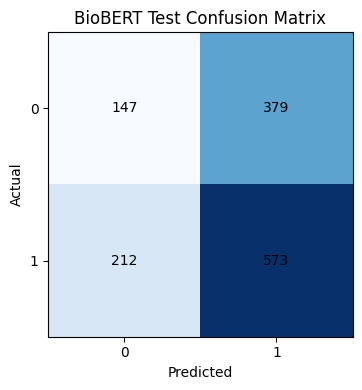

In [16]:
os.environ['MPLCONFIGDIR'] = str(OUTPUT_DIR / '.matplotlib')
(OUTPUT_DIR / '.matplotlib').mkdir(parents=True, exist_ok=True)
import matplotlib.pyplot as plt

cm = confusion_matrix(test_df['label'], test_pred_labels)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_title('BioBERT Test Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.tight_layout()
plt.show()


In [17]:
if 'dev_metrics' not in globals() or 'test_metrics' not in globals():
    dev_metrics = trainer.evaluate(dev_dataset)
    test_metrics = trainer.evaluate(test_dataset)

if 'test_pred_labels' not in globals() or 'test_probabilities' not in globals():
    test_predictions = trainer.predict(test_dataset)
    test_pred_labels = np.argmax(test_predictions.predictions, axis=-1)
    test_probabilities = torch.softmax(torch.tensor(test_predictions.predictions), dim=1).numpy()

trainer.save_model(str(MODEL_DIR))
tokenizer.save_pretrained(str(MODEL_DIR))

metrics = {
    'model_name': MODEL_NAME,
    'max_length': MAX_LENGTH,
    'num_epochs': NUM_EPOCHS,
    'train_batch_size': TRAIN_BATCH_SIZE,
    'eval_batch_size': EVAL_BATCH_SIZE,
    'gradient_accumulation_steps': GRADIENT_ACCUMULATION_STEPS,
    'learning_rate': LEARNING_RATE,
    'device': DEVICE,
    'train_rows': int(len(train_df)),
    'dev_rows': int(len(dev_df)),
    'test_rows': int(len(test_df)),
    'dev_metrics': {k: float(v) for k, v in dev_metrics.items() if isinstance(v, (int, float))},
    'test_metrics': {k: float(v) for k, v in test_metrics.items() if isinstance(v, (int, float))},
}

(OUTPUT_DIR / 'biobert_metrics.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')

prediction_df = test_df[['dataset', 'split', 'record_id', 'label', 'text']].copy()
prediction_df['prediction'] = test_pred_labels
prediction_df['prob_class_0'] = test_probabilities[:, 0]
prediction_df['prob_class_1'] = test_probabilities[:, 1]
prediction_df.to_csv(OUTPUT_DIR / 'biobert_test_predictions.csv', index=False)

print('Saved model to:', MODEL_DIR)
print('Saved outputs to:', OUTPUT_DIR)
metrics


Saved model to: C:\Users\ribam\Desktop\Reseach\Dataset\model\biobert_fakehealth_healthfact
Saved outputs to: C:\Users\ribam\Desktop\Reseach\Dataset\output\biobert_fakehealth_healthfact


{'model_name': 'dmis-lab/biobert-base-cased-v1.1',
 'max_length': 256,
 'num_epochs': 5,
 'train_batch_size': 4,
 'eval_batch_size': 4,
 'gradient_accumulation_steps': 2,
 'learning_rate': 2e-05,
 'device': 'cpu',
 'train_rows': 9588,
 'dev_rows': 1332,
 'test_rows': 1311,
 'dev_metrics': {'eval_loss': 0.4946806728839874,
  'eval_accuracy': 0.7424924924924925,
  'eval_precision': 0.733862959285005,
  'eval_recall': 0.9078624078624079,
  'eval_f1': 0.8116419549697969,
  'eval_runtime': 121.7321,
  'eval_samples_per_second': 10.942,
  'eval_steps_per_second': 2.736,
  'epoch': 5.0},
 'test_metrics': {'eval_loss': 0.4983121454715729,
  'eval_accuracy': 0.7337909992372235,
  'eval_precision': 0.7289915966386554,
  'eval_recall': 0.8840764331210191,
  'eval_f1': 0.7990788716177317,
  'eval_runtime': 126.7534,
  'eval_samples_per_second': 10.343,
  'eval_steps_per_second': 2.588,
  'epoch': 5.0}}

 this is BioBERT baseline, the best next comparison would be **PubMedBERT** using the exact same split strategy and evaluation pipeline.